In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

DATASET_PATH = "/content/drive/MyDrive/for-norm"

print("Dataset Exists :", os.path.exists(DATASET_PATH))
print()

for item in os.listdir(DATASET_PATH):
    print(item)

Dataset Exists : True

validation
testing
training


In [4]:
train_real = os.path.join(DATASET_PATH, "training", "real")
train_fake = os.path.join(DATASET_PATH, "training", "fake")

val_real = os.path.join(DATASET_PATH, "validation", "real")
val_fake = os.path.join(DATASET_PATH, "validation", "fake")

test_real = os.path.join(DATASET_PATH, "testing", "real")
test_fake = os.path.join(DATASET_PATH, "testing", "fake")

print("Training Real :", len(os.listdir(train_real)))
print("Training Fake :", len(os.listdir(train_fake)))

print()

print("Validation Real :", len(os.listdir(val_real)))
print("Validation Fake :", len(os.listdir(val_fake)))

print()

print("Testing Real :", len(os.listdir(test_real)))
print("Testing Fake :", len(os.listdir(test_fake)))

Training Real : 27008
Training Fake : 26954

Validation Real : 5416
Validation Fake : 5398

Testing Real : 2264
Testing Fake : 2370


# Audio Sample Inspection

Before training a model, we inspect audio samples to understand:

- Audio format
- Sample rate
- Duration
- Waveform characteristics

This helps verify that the dataset has been loaded correctly.

In [5]:
!pip install librosa soundfile matplotlib seaborn -q

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

In [7]:
sample_real = os.path.join(
    train_real,
    os.listdir(train_real)[0]
)

print("Sample Audio:")
print(sample_real)

Sample Audio:
/content/drive/MyDrive/for-norm/training/real/file8828.wav_16k.wav_norm.wav_mono.wav_silence.wav


In [8]:
audio, sr = librosa.load(
    sample_real,
    sr=None
)

duration = len(audio) / sr

print("Sample Rate :", sr)
print("Duration :", duration)
print("Total Samples :", len(audio))

Sample Rate : 16000
Duration : 1.968375
Total Samples : 31494


# Waveform Visualization

The waveform represents amplitude variation with time.

This visualization helps identify clipping,
silence regions, and recording characteristics.

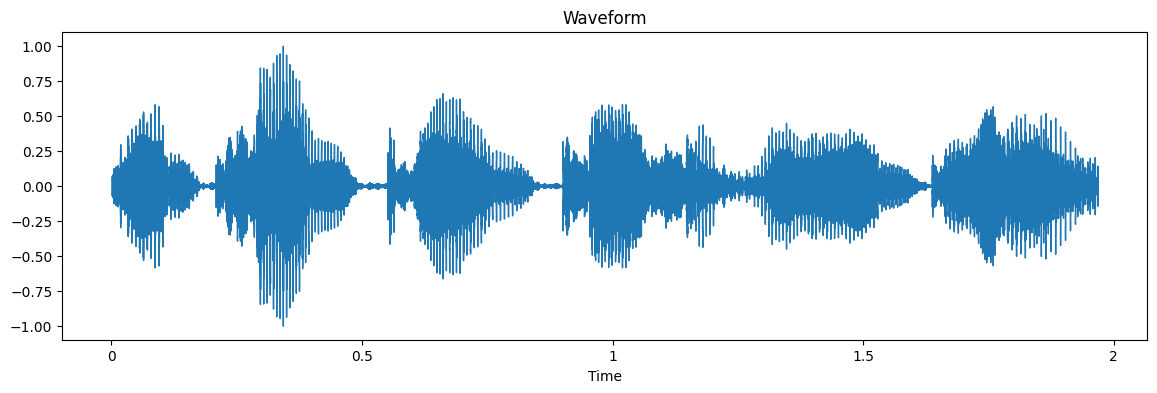

In [9]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Waveform")
plt.show()

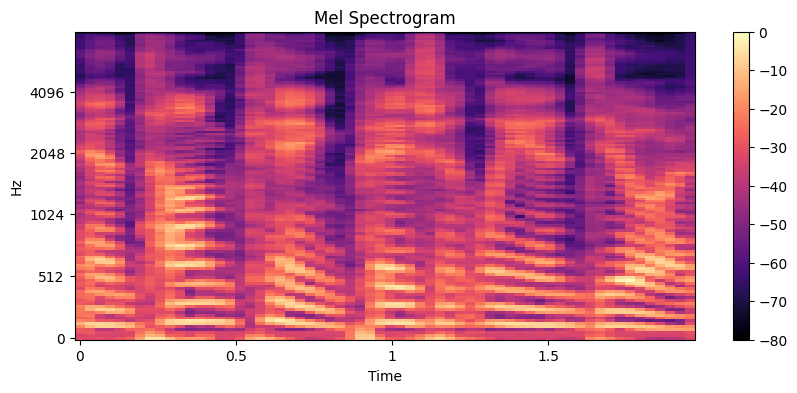

In [10]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

# Prototype Dataset Creation

The full dataset contains more than 50,000 audio files.

To quickly verify the pipeline, we first create a smaller subset.

This allows:

- Faster experimentation
- Debugging
- Model verification

Once validated, the same pipeline can be scaled to the full dataset.

In [11]:
import random

NUM_REAL = 2000
NUM_FAKE = 2000

real_files = random.sample(
    os.listdir(train_real),
    NUM_REAL
)

fake_files = random.sample(
    os.listdir(train_fake),
    NUM_FAKE
)

print("Selected Real :", len(real_files))
print("Selected Fake :", len(fake_files))

Selected Real : 2000
Selected Fake : 2000


# MFCC Feature Extraction

MFCC (Mel Frequency Cepstral Coefficients) capture
important speech characteristics such as timbre,
pitch patterns, and vocal tract information.

These features are widely used in speech recognition
and deepfake audio detection.

In [12]:
def extract_features(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc_mean = np.mean(
        mfcc.T,
        axis=0
    )

    return mfcc_mean

In [13]:
X = []
y = []

In [14]:
from tqdm import tqdm

for file in tqdm(real_files):

    path = os.path.join(
        train_real,
        file
    )

    try:

        feature = extract_features(path)

        X.append(feature)
        y.append(0)

    except:
        pass

100%|██████████| 2000/2000 [11:56<00:00,  2.79it/s]


In [15]:
for file in tqdm(fake_files):

    path = os.path.join(
        train_fake,
        file
    )

    try:

        feature = extract_features(path)

        X.append(feature)
        y.append(1)

    except:
        pass

100%|██████████| 2000/2000 [11:33<00:00,  2.88it/s]


In [16]:
X = np.array(X)
y = np.array(y)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)

Feature Shape : (4000, 40)
Label Shape : (4000,)


# Baseline Model Training

A Random Forest classifier is used as the first baseline.

Advantages:

- Fast training
- Handles non-linear patterns
- Provides a strong baseline for comparison

This baseline helps verify that the extracted audio
features contain useful information for distinguishing
between genuine and deepfake speech.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (3200, 40)
Test Shape : (800, 40)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Model Created")

Model Created


In [19]:
model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


# Model Evaluation

The trained model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide insight into how well the
classifier distinguishes genuine and deepfake audio.

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy :", accuracy)

Accuracy : 0.975


In [21]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       400
           1       0.98      0.97      0.97       400

    accuracy                           0.97       800
   macro avg       0.98      0.98      0.97       800
weighted avg       0.98      0.97      0.97       800



In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[391   9]
 [ 11 389]]


# Official Validation Evaluation

The model is now evaluated on the provided validation
dataset.

This gives a more realistic estimate of performance on
unseen audio samples.

In [23]:
VAL_SAMPLES = 2000

In [24]:
import random

val_real_files = random.sample(
    os.listdir(val_real),
    min(VAL_SAMPLES, len(os.listdir(val_real)))
)

val_fake_files = random.sample(
    os.listdir(val_fake),
    min(VAL_SAMPLES, len(os.listdir(val_fake)))
)

print("Validation Real :", len(val_real_files))
print("Validation Fake :", len(val_fake_files))

Validation Real : 2000
Validation Fake : 2000


In [25]:
X_val = []
y_val = []

In [26]:
for file in tqdm(val_real_files):

    path = os.path.join(
        val_real,
        file
    )

    try:

        feature = extract_features(path)

        X_val.append(feature)
        y_val.append(0)

    except:
        pass

 71%|███████   | 1414/2000 [03:00<00:12, 45.25it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(
100%|██████████| 2000/2000 [03:18<00:00, 10.10it/s]


In [27]:
for file in tqdm(val_fake_files):

    path = os.path.join(
        val_fake,
        file
    )

    try:

        feature = extract_features(path)

        X_val.append(feature)
        y_val.append(1)

    except:
        pass

100%|██████████| 2000/2000 [12:21<00:00,  2.70it/s]


In [28]:
X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_val.shape)
print(y_val.shape)

(4000, 40)
(4000,)


In [29]:
val_predictions = model.predict(
    X_val
)

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

print("Validation Accuracy :", val_accuracy)

Validation Accuracy : 0.97575


In [31]:
print(
    classification_report(
        y_val,
        val_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2000
           1       0.97      0.98      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



# Model Saving

The trained Random Forest model is saved to disk.

This model will later be used for:

- Inference
- Streamlit Deployment
- External Audio Testing

In [32]:
import joblib

joblib.dump(
    model,
    "deepfake_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [33]:
import os

print(
    os.path.exists(
        "deepfake_model.pkl"
    )
)

True


# Confusion Matrix Visualization

A confusion matrix provides insight into the
classification performance of the model.

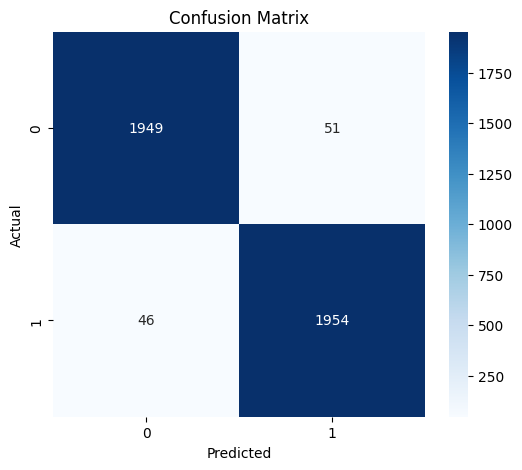

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    val_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [35]:
print(
    os.path.exists(
        "confusion_matrix.png"
    )
)

True


In [36]:
from google.colab import files

files.download(
    "deepfake_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from google.colab import files

files.download(
    "confusion_matrix.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Inference Pipeline

This section creates a reusable prediction function.

The function:

1. Accepts a new audio file.
2. Extracts MFCC features.
3. Loads the trained model.
4. Predicts whether the audio is Genuine or Deepfake.
5. Returns a confidence score.

In [38]:
def predict_audio(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    features = np.mean(
        mfcc.T,
        axis=0
    ).reshape(1, -1)

    prediction = model.predict(
        features
    )[0]

    probability = model.predict_proba(
        features
    )[0]

    confidence = np.max(
        probability
    ) * 100

    label = (
        "Genuine"
        if prediction == 0
        else "Deepfake"
    )

    return label, confidence

In [39]:
sample_test = os.path.join(
    test_real,
    os.listdir(test_real)[0]
)

sample_test

'/content/drive/MyDrive/for-norm/testing/real/file2147.wav_16k.wav_norm.wav_mono.wav_silence.wav'

In [40]:
label, confidence = predict_audio(
    sample_test
)

print("Prediction :", label)
print("Confidence :", confidence)

Prediction : Genuine
Confidence : 63.5


In [41]:
sample_fake = os.path.join(
    test_fake,
    os.listdir(test_fake)[0]
)

label, confidence = predict_audio(
    sample_fake
)

print("Prediction :", label)
print("Confidence :", confidence)

Prediction : Deepfake
Confidence : 59.0


In [43]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder created")

Project folder created


In [44]:
import joblib

joblib.dump(
    model,
    f"{PROJECT_DIR}/deepfake_model.pkl"
)

print("Model saved")

Model saved


In [45]:
predict_code = '''
import sys
import joblib
import librosa
import numpy as np

model = joblib.load("deepfake_model.pkl")

def extract_features(file_path):

    audio, sr = librosa.load(file_path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    feature = np.mean(
        mfcc.T,
        axis=0
    )

    return feature.reshape(1,-1)

audio_path = sys.argv[1]

features = extract_features(audio_path)

prediction = model.predict(features)[0]

probability = model.predict_proba(features)[0]

confidence = np.max(probability)*100

label = "Genuine" if prediction == 0 else "Deepfake"

print(f"Prediction : {label}")
print(f"Confidence : {confidence:.2f}%")
'''

with open(
    f"{PROJECT_DIR}/predict.py",
    "w"
) as f:

    f.write(predict_code)

print("predict.py created")

predict.py created


In [46]:
app_code = '''
import streamlit as st
import joblib
import librosa
import numpy as np

model = joblib.load("deepfake_model.pkl")

def extract_features(uploaded_file):

    audio, sr = librosa.load(
        uploaded_file,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    feature = np.mean(
        mfcc.T,
        axis=0
    )

    return feature.reshape(1,-1)

st.title("Deepfake Audio Detection")

uploaded_file = st.file_uploader(
    "Upload Audio",
    type=["wav","mp3","flac"]
)

if uploaded_file:

    features = extract_features(
        uploaded_file
    )

    prediction = model.predict(
        features
    )[0]

    probability = model.predict_proba(
        features
    )[0]

    confidence = np.max(
        probability
    )*100

    if prediction == 0:
        st.success(
            f"Genuine Audio ({confidence:.2f}%)"
        )
    else:
        st.error(
            f"Deepfake Audio ({confidence:.2f}%)"
        )
'''

with open(
    f"{PROJECT_DIR}/app.py",
    "w"
) as f:

    f.write(app_code)

print("app.py created")

app.py created


In [47]:
requirements = """
numpy
pandas
librosa
scikit-learn
matplotlib
seaborn
streamlit
joblib
tqdm
soundfile
"""

with open(
    f"{PROJECT_DIR}/requirements.txt",
    "w"
) as f:

    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [54]:
readme = """
# Deepfake Audio Detection

## Validation Metrics

Validation Accuracy : 97.57%
F1 Score            : 97.8%
EER                 : 2.50%

## Model

Random Forest Classifier

## Features

MFCC (40 coefficients)

## Run

streamlit run app.py

## Prediction

python predict.py audio.wav
"""

with open(
    f"{PROJECT_DIR}/README.md",
    "w"
) as f:

    f.write(readme)

print("README.md created")

README.md created


In [55]:
import os

print(os.listdir(PROJECT_DIR))

['deepfake_model.pkl', 'predict.py', 'app.py', 'requirements.txt', 'README.md']


In [56]:
from sklearn.metrics import roc_curve
import numpy as np

probs = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, probs)

fnr = 1 - tpr

eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]

print("Equal Error Rate (EER): {:.4f}".format(eer))

Equal Error Rate (EER): 0.0250
